Starting Strict OccamNet Training...
Epoch 0: Best MSE = 1133.066284
Epoch 50: Best MSE = 41.509861
Epoch 100: Best MSE = 38.455235
Epoch 150: Best MSE = 28.325075
Epoch 200: Best MSE = 38.972374
Epoch 250: Best MSE = 0.002958
Epoch 300: Best MSE = 0.002408
Epoch 350: Best MSE = 0.002423
Epoch 400: Best MSE = 0.002563
Epoch 450: Best MSE = 0.002892
Epoch 500: Best MSE = 0.002424
Epoch 550: Best MSE = 0.002764
Epoch 600: Best MSE = 0.002414
Epoch 650: Best MSE = 0.002415
Epoch 700: Best MSE = 0.002413
Epoch 750: Best MSE = 0.002581
Epoch 800: Best MSE = 0.002411
Epoch 850: Best MSE = 0.002415
Epoch 900: Best MSE = 0.002458
Epoch 950: Best MSE = 0.003857
Generating final visualization...
--------------------------------------------------
Ground Truth Formula: y = 2.5 * sin(3 * x) + 0.5 * x^2 - 1.0
Predicted Formula:    y = (((x / x) + (x * x)) + 1.50)
--------------------------------------------------
Result saved to occamnet_result.png


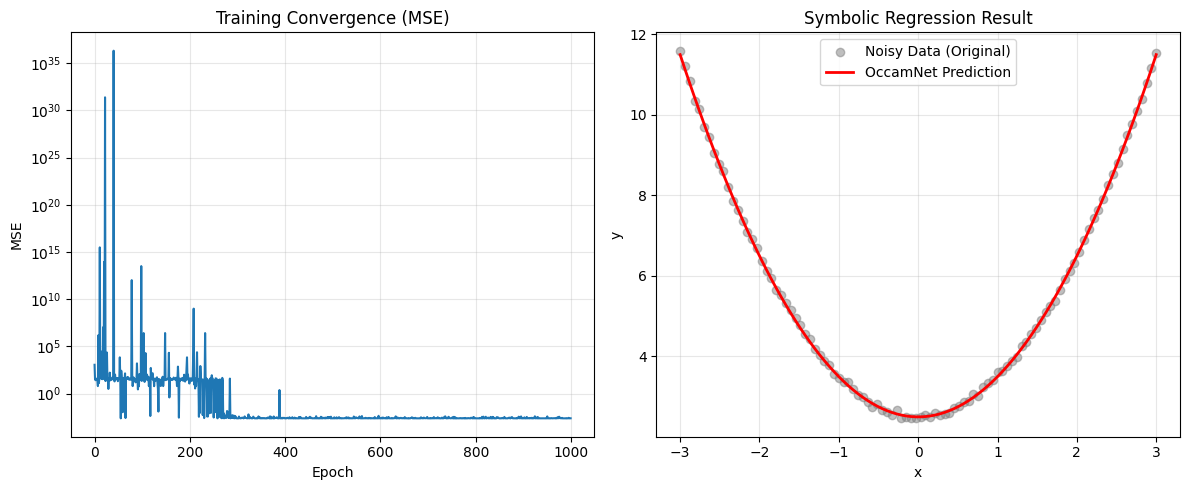

In [ ]:
# ----- OccamNet Full Implementation (Strict Adherence to Paper) ----- #

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

# ----- Set random seed & Device ----- #
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----- Primitive Library with Constants Support ----- #
class PrimitiveLibrary:
    def __init__(self, device):
        self.device = device
        # Operations: (name, arity, function, has_constant)
        # has_constant: If True, this op requires a learned constant parameter (e.g., c * x)
        self.ops = [
            ('sin', 1, torch.sin, False),
            ('cos', 1, torch.cos, False),
            ('exp', 1, torch.exp, False),
            ('sqr', 1, lambda x: x ** 2, False),
            ('neg', 1, lambda x: -x, False),
            ('add', 2, lambda x, y: x + y, False),
            ('sub', 2, lambda x, y: x - y, False),
            ('mul', 2, lambda x, y: x * y, False),
            ('div', 2, lambda x, y: x / (y + 1e-7), False),
            # Operations with constants (Section 6.1.8)
            ('add_c', 1, lambda x, c: x + c, True),
            ('mul_c', 1, lambda x, c: x * c, True),
            ('rbf', 1, lambda x, c: torch.exp(-(x**2)/(2*(c**2+1e-5))), True) # Radial Basis
        ]
        self.n_primitives = len(self.ops)

    def apply(self, op_idx, args, constant=None):
        func = self.ops[op_idx][2]
        has_c = self.ops[op_idx][3]
        if has_c:
            return func(args[0], constant)
        else:
            return func(*args)

    def get_arity(self, op_idx):
        return self.ops[op_idx][1]

    def get_name(self, op_idx):
        return self.ops[op_idx][0]

# ----- Regularizer for Occam's Razor (Section 6.1.10) ----- #
class OccamRegularizer:
    def __init__(self, w_phi=0.5, w_xi=0.1, w_gamma=0.1, w_psi=0.1):
        self.w_phi = w_phi     # Trivial operations
        self.w_xi = w_xi       # Complexity (op count)
        self.w_gamma = w_gamma # Constants count
        self.w_psi = w_psi     # Trivial approximations (clustering)

    def compute_penalty(self, structure_info, outputs, constants_used):
        # 1. Complexity (xi)
        penalty_xi = len(structure_info) * self.w_xi
        
        # 2. Constants Count (gamma)
        penalty_gamma = len(constants_used) * self.w_gamma
        
        # 3. Trivial Approximations (psi) - check clustering
        # Robustly handle outputs that might be NaN/Inf during penalty check
        if torch.isnan(outputs).any() or torch.isinf(outputs).any():
             return 100.0 # High penalty for unstable functions
             
        mean_val = torch.mean(outputs)
        dist_to_int = torch.min(torch.abs(mean_val - torch.tensor([0.0, 1.0, -1.0], device=outputs.device)))
        penalty_psi = 0.0
        if dist_to_int < 1e-3:
            penalty_psi = self.w_psi
            
        penalty_phi = 0.0 
        return penalty_xi + penalty_gamma + penalty_psi + penalty_phi

# ----- OccamNet Model ----- #
class OccamNet(nn.Module):
    def __init__(self, depth, n_inputs, temperature=10.0, last_layer_temp=5.0, recurrence_depth=1, device='cpu'):
        super().__init__()
        self.depth = depth
        self.n_inputs = n_inputs 
        self.T = temperature
        self.T_last = last_layer_temp
        self.recurrence_depth = recurrence_depth 
        self.device = device
        self.primitives = PrimitiveLibrary(device)
        self.M = sum([op[1] for op in self.primitives.ops])
        
        self.weights = nn.ParameterList()
        for l in range(depth):
            n_in_features = self.n_inputs + l * self.primitives.n_primitives
            w = nn.Parameter(torch.zeros(self.M, n_in_features)) # Inititalize by 0
            self.weights.append(w)
            
        last_n_in = self.n_inputs + depth * self.primitives.n_primitives
        self.output_weight = nn.Parameter(torch.zeros(1, last_n_in))
        
        self.init_weights_equal_prob()

    def init_weights_equal_prob(self):
        current_image_probs = [1.0] * self.n_inputs
        
        for l in range(self.depth):
            n_in = len(current_image_probs)
            target_w = []
            for p in current_image_probs:
                # Safety for very small p
                safe_p = max(p, 1e-9)
                val = self.T * math.log(1.0 / safe_p)
                target_w.append(val)
            
            target_w = torch.tensor(target_w, device=self.device)
            target_w = target_w - torch.mean(target_w)
            
            with torch.no_grad():
                self.weights[l].copy_(target_w.unsqueeze(0).expand(self.M, -1))
                
            p_arg = 1.0 / n_in
            for _ in range(self.primitives.n_primitives):
                current_image_probs.append(p_arg) 

        target_w = []
        for p in current_image_probs:
            safe_p = max(p, 1e-9)
            val = self.T_last * math.log(1.0 / safe_p)
            target_w.append(val)
        target_w = torch.tensor(target_w, device=self.device)
        target_w = target_w - torch.mean(target_w)
        with torch.no_grad():
            self.output_weight.copy_(target_w.unsqueeze(0))

    def get_connection_probs(self, layer_idx, is_output=False):
        if is_output:
            temp = self.T_last
            w = self.output_weight
        else:
            temp = self.T
            w = self.weights[layer_idx]
        return F.softmax(w / temp, dim=-1)

    def sample_connections(self, layer_idx, num_samples, is_output=False):
        probs = self.get_connection_probs(layer_idx, is_output)
        
        # Check for NaNs in probabilities (which implies NaNs in weights)
        if torch.isnan(probs).any():
             # Fallback to uniform if weights are corrupted (or handle error gracefully)
             # But here we raise error to signal training failure earlier
             raise RuntimeError("Weights contain NaNs, causing NaN probabilities.")
             
        probs_expanded = probs.unsqueeze(0).expand(num_samples, -1, -1)
        flat_probs = probs_expanded.reshape(-1, probs.shape[-1])
        
        # Multinomial can fail if all probs are 0, but Softmax guarantees sum to 1.
        # It fails if there are NaNs or negatives.
        sample_idx = torch.multinomial(flat_probs, 1)
        return sample_idx.reshape(num_samples, -1)

    def evaluate(self, x, layer_connections, output_indices, constants_list):
        # x: (batch_size, n_inputs)
        batch_size = x.shape[0]
        num_samples = layer_connections[0].shape[0]
        
        current_input = x
        final_output = None
        
        for r_step in range(self.recurrence_depth):
            if r_step > 0:
                if r_step == 1:
                     # x.T is (Features, Batch) -> unsqueeze -> (1, Feat, Batch)
                     current_input_exp = x.T.unsqueeze(0).expand(num_samples, -1, -1).clone()
                
                # Update Feature 0 with previous output
                if final_output is not None:
                     current_input_exp[:, 0, :] = final_output
                image_stack = [current_input_exp] 
            else:
                x_expanded = x.T.unsqueeze(0).expand(num_samples, -1, -1)
                image_stack = [x_expanded]

            # Forward through layers
            const_ptr_global = 0 
            
            for l in range(self.depth):
                available_images = torch.cat(image_stack, dim=1)
                indices = layer_connections[l].unsqueeze(-1).expand(-1, -1, batch_size)
                arguments = torch.gather(available_images, 1, indices)
                
                layer_outputs = []
                arg_pointer = 0
                
                for i in range(self.primitives.n_primitives):
                    arity = self.primitives.get_arity(i)
                    has_c = self.primitives.ops[i][3]
                    
                    args = []
                    for _ in range(arity):
                        args.append(arguments[:, arg_pointer, :])
                        arg_pointer += 1
                    
                    if has_c:
                        c_vals = constants_list[const_ptr_global] # (num_samples, 1)
                        out = self.primitives.apply(i, args, c_vals)
                        const_ptr_global += 1
                    else:
                        out = self.primitives.apply(i, args)
                    
                    layer_outputs.append(out.unsqueeze(1))
                    
                layer_outputs_tensor = torch.cat(layer_outputs, dim=1)
                image_stack.append(layer_outputs_tensor)
                
            available_images = torch.cat(image_stack, dim=1)
            final_idx = output_indices.unsqueeze(-1).expand(-1, -1, batch_size)
            y_pred = torch.gather(available_images, 1, final_idx).squeeze(1)
            final_output = y_pred

        return final_output

    def forward(self, x, num_samples=1):
        layer_connections = []
        for l in range(self.depth):
            layer_connections.append(self.sample_connections(l, num_samples))
        output_indices = self.sample_connections(0, num_samples, is_output=True)
        
        n_const_prims = sum([1 for op in self.primitives.ops if op[3]])
        total_const_params = n_const_prims * self.depth
        
        # Init constants: (num_samples, 1)
        init_constants = [torch.randn(num_samples, 1, device=self.device, requires_grad=True) 
                          for _ in range(total_const_params)]
        
        return layer_connections, output_indices, init_constants

    def compute_log_prob(self, layer_connections, output_indices):
        total_log_prob = torch.zeros(layer_connections[0].shape[0], device=self.device)
        for l in range(self.depth):
            indices = layer_connections[l]
            probs = self.get_connection_probs(l, is_output=False)
            probs_expanded = probs.unsqueeze(0).expand(indices.shape[0], -1, -1)
            selected_probs = torch.gather(probs_expanded, 2, indices.unsqueeze(-1)).squeeze(-1)
            total_log_prob += torch.sum(torch.log(selected_probs + 1e-9), dim=1)
        output_probs = self.get_connection_probs(0, is_output=True)
        output_probs_expanded = output_probs.unsqueeze(0).expand(output_indices.shape[0], -1, -1)
        selected_out_prob = torch.gather(output_probs_expanded, 2, output_indices.unsqueeze(-1)).squeeze(-1)
        total_log_prob += torch.sum(torch.log(selected_out_prob + 1e-9), dim=1)
        return total_log_prob

    # ----- Stringify Method for Formula Interpretation ----- #
    def stringify(self, layer_connections, output_indices, feature_names, constants_list=None):
        # Recursively reconstruct the string expression for the best sample
        # Assumes inputs are sliced for a single sample (the best one)
        node_strings = list(feature_names) 
        
        const_ptr_global = 0
        
        for l in range(self.depth):
            indices = layer_connections[l][0] 
            arg_ptr = 0
            
            for p_idx in range(self.primitives.n_primitives):
                prim_name = self.primitives.get_name(p_idx)
                arity = self.primitives.get_arity(p_idx)
                has_c = self.primitives.ops[p_idx][3]
                
                args_str = []
                for _ in range(arity):
                    input_idx = indices[arg_ptr].item()
                    args_str.append(node_strings[input_idx])
                    arg_ptr += 1
                
                c_str = ""
                if has_c and constants_list is not None:
                    c_val = constants_list[const_ptr_global].item()
                    c_str = f"{c_val:.2f}"
                    const_ptr_global += 1
                
                if arity == 1:
                    if has_c:
                         if prim_name == 'add_c': expr = f"({args_str[0]} + {c_str})"
                         elif prim_name == 'mul_c': expr = f"({args_str[0]} * {c_str})"
                         elif prim_name == 'rbf': expr = f"rbf({args_str[0]}, c={c_str})"
                         else: expr = f"{prim_name}({args_str[0]}, {c_str})"
                    else:
                        expr = f"{prim_name}({args_str[0]})"
                elif arity == 2:
                    symbol = prim_name
                    if prim_name == 'add': symbol = '+'
                    if prim_name == 'sub': symbol = '-'
                    if prim_name == 'mul': symbol = '*'
                    if prim_name == 'div': symbol = '/'
                    expr = f"({args_str[0]} {symbol} {args_str[1]})"
                
                node_strings.append(expr)
                
        final_idx = output_indices[0].item()
        return node_strings[final_idx]

# ----- Trainer with Inner Loop & Regularization ----- #
class OccamNetTrainer:
    def __init__(self, model, lr=1e-2, top_k=5, sigma_sq=0.1, implicit_mode=False):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.top_k = top_k
        self.sigma_sq = sigma_sq
        self.implicit_mode = implicit_mode
        self.regularizer = OccamRegularizer()
        
    def fit_constants(self, X, y, layer_connections, output_indices, init_constants):
        # Using Adam for stability over LBFGS on batches
        const_optimizer = torch.optim.Adam(init_constants, lr=0.1)
        
        for _ in range(5):
            const_optimizer.zero_grad()
            preds = self.model.evaluate(X, layer_connections, output_indices, init_constants)
            
            # Handle potential NaNs in preds during constant fitting
            if torch.isnan(preds).any() or torch.isinf(preds).any():
                # If optimization explodes, break early or handle? 
                # Here we just zero grad and stop to avoid tainting constants further
                break
                
            if self.implicit_mode:
                loss = torch.sum(preds**2) 
            else:
                loss = torch.sum((preds - y.unsqueeze(0))**2)
            
            loss.backward()
            const_optimizer.step()
            
        return init_constants

    def compute_fitness(self, y_pred, y_target, connections, out_indices, constants):
        # --- ROBUST FITNESS CALCULATION --- #
        
        # 1. Calculate MSE
        if self.implicit_mode:
            sq_diff = y_pred**2
        else:
            sq_diff = (y_pred - y_target.unsqueeze(0))**2
            
        # 2. Check for NaNs/Infs in output
        # If a function produces NaN/Inf, it is a bad function.
        # We replace the squared difference with a very large number (1e9)
        # This causes exp(-MSE) to be 0 (fitness = 0).
        is_unstable = torch.isnan(sq_diff) | torch.isinf(sq_diff)
        sq_diff = torch.where(is_unstable, torch.tensor(1e9, device=sq_diff.device), sq_diff)
        
        mse = torch.mean(sq_diff, dim=1)
            
        fitness = (1 / math.sqrt(2 * math.pi * self.sigma_sq)) * torch.exp(-mse / (2 * self.sigma_sq))
        
        # Double check fitness
        fitness = torch.nan_to_num(fitness, nan=0.0)
        
        # 3. Regularization
        penalties = []
        for i in range(len(mse)):
            sample_out = y_pred[i]
            # Pass output for stability check in Regularizer
            penalty = self.regularizer.compute_penalty([], sample_out, constants)
            penalties.append(penalty)
        
        penalties = torch.tensor(penalties, device=y_pred.device)
        s = (1 / math.sqrt(2 * math.pi * self.sigma_sq))
        regularized_fitness = fitness - s * penalties
        
        # Clip fitness to be non-negative
        regularized_fitness = torch.clamp(regularized_fitness, min=0.0)
        
        return regularized_fitness, mse

    def fit(self, X, y, epochs=500, num_samples=100):
        history = {'best_mse': []}
        
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            
            # 1. Sample Structure & Init Constants
            connections, out_indices, init_constants = self.model(X, num_samples)
            
            # 2. Constant Fitting (Inner Loop)
            fitted_constants = self.fit_constants(X, y, connections, out_indices, init_constants)
            
            # 3. Evaluate with Fitted Constants
            with torch.no_grad():
                y_preds = self.model.evaluate(X, connections, out_indices, fitted_constants)
            
            # 4. Compute Regularized Fitness
            fitness, mses = self.compute_fitness(y_preds, y, connections, out_indices, fitted_constants)
            
            # 5. Risk-Seeking Update
            top_k_vals, top_k_indices = torch.topk(fitness, self.top_k)
            
            log_probs = self.model.compute_log_prob(connections, out_indices)
            selected_log_probs = log_probs[top_k_indices]
            selected_fitness = top_k_vals.detach()
            
            # --- NaN Loss Guard --- #
            loss = -torch.sum(selected_fitness * selected_log_probs)
            
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Warning: NaN/Inf loss at epoch {epoch}. Skipping update.")
                continue
            
            loss.backward()
            
            # --- Gradient Clipping --- #
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            best_mse = mses[top_k_indices[0]].item()
            history['best_mse'].append(best_mse)
            
            if epoch % 50 == 0:
                print(f"Epoch {epoch}: Best MSE = {best_mse:.6f}")
                
        return history

# ----- Mock Data & Visualization ----- #
def generate_complex_data(seq_length=100):
    # Generating more complex data: y = 2.5 * sin(3 * x) + 0.5 * x^2 - 1.0
    # This requires fitting constants (2.5, 3, 0.5, -1.0) and structure (sin, sqr, add)
    x = torch.linspace(-3, 3, seq_length).unsqueeze(1)
#     y = 2.5 * torch.sin(3 * x) + 0.5 * x**2 - 1.0
    y = x**2 + 2.5
    y += torch.randn_like(y) * 0.05
    return x.to(DEVICE), y.squeeze().to(DEVICE)

# Execution
X_train, y_train = generate_complex_data()
model = OccamNet(depth=3, n_inputs=1, temperature=1.0, recurrence_depth=1, device=DEVICE).to(DEVICE)
trainer = OccamNetTrainer(model, lr=0.05, top_k=10, implicit_mode=False)

print("Starting Strict OccamNet Training...")
history = trainer.fit(X_train, y_train, epochs=1000, num_samples=100)

# --- Visualization with Original vs Predicted Sequence --- #
print("Generating final visualization...")
plt.figure(figsize=(12, 5))

# Plot 1: MSE Convergence
plt.subplot(1, 2, 1)
plt.plot(history['best_mse'])
plt.yscale('log')
plt.title('Training Convergence (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)

# Plot 2: Prediction vs Data
# Need to perform one final inference to get the best prediction
connections, out_indices, init_constants = model(X_train, num_samples=100)
# Constant fitting for these samples
fitted_constants = trainer.fit_constants(X_train, y_train, connections, out_indices, init_constants)
# Evaluation
with torch.no_grad():
    final_preds = model.evaluate(X_train, connections, out_indices, fitted_constants)
    # Get fitness to identify the best sample
    fitness, mses = trainer.compute_fitness(final_preds, y_train, connections, out_indices, fitted_constants)
    best_idx = torch.argmax(fitness)
    best_pred = final_preds[best_idx].cpu().numpy()

# Extract and Print Formula
# Slice tensors for the best index only
best_conns_sliced = [c[best_idx:best_idx+1] for c in connections]
best_out_idx_sliced = out_indices[best_idx:best_idx+1]
best_consts_sliced = [c[best_idx:best_idx+1] for c in fitted_constants]

expr_str = model.stringify(best_conns_sliced, best_out_idx_sliced, ["x"], best_consts_sliced)
print("-" * 50)
print("Ground Truth Formula: y = 2.5 * sin(3 * x) + 0.5 * x^2 - 1.0")
print(f"Predicted Formula:    y = {expr_str}")
print("-" * 50)

# Prepare numpy arrays for plotting
x_plot = X_train.cpu().numpy().flatten()
y_plot = y_train.cpu().numpy().flatten()
# Sort for clean line plotting
sort_idx = np.argsort(x_plot)
x_sorted = x_plot[sort_idx]
pred_sorted = best_pred[sort_idx]

plt.subplot(1, 2, 2)
plt.scatter(x_plot, y_plot, color='gray', alpha=0.5, label='Noisy Data (Original)')
plt.plot(x_sorted, pred_sorted, color='red', linewidth=2, label='OccamNet Prediction')
plt.title('Symbolic Regression Result')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('occamnet_result.png')
print("Result saved to occamnet_result.png")